# Finnish BERT — Embedding Quality Evaluation

In [1]:
## Step 1: Imports and Setup
%matplotlib inline
import importlib.util
import os
import sys

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Get the project root directory
notebook_dir = os.getcwd()
if os.path.basename(notebook_dir) == "notebooks":
    project_root = os.path.dirname(notebook_dir)
else:
    project_root = notebook_dir

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Working directory: {os.getcwd()}")
os.makedirs("outputs", exist_ok=True)

# Load 07_evaluate.py via importlib
print(f"Loading evaluate module from: {os.path.join(project_root, 'src/07_evaluate.py')}")
spec = importlib.util.spec_from_file_location(
    "evaluate", os.path.join(project_root, "src/07_evaluate.py")
)
ev = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ev)

print("07_evaluate.py loaded.", flush=True)
print(f"Test sentences: {len(ev.FINNISH_TEST_SENTENCES)}", flush=True)
print(f"Categories    : {list(ev.CATEGORIES.keys())}", flush=True)

Working directory: /Users/tyerdogan/PycharmProjects/finnish-embeddings
Loading evaluate module from: /Users/tyerdogan/PycharmProjects/finnish-embeddings/src/07_evaluate.py
07_evaluate.py loaded.
Test sentences: 40
Categories    : ['Eläimet (Animals)', 'Ajoneuvot (Vehicles)', 'Luonto (Nature)', 'Ihmiset (People)', 'Ruoka (Food)']


In [2]:
## Step 2: Load Model and Encode All 40 Sentences
# ev.main() finds the latest checkpoint automatically (checkpoints/ or models/),
# loads both a trained model and a random-init baseline, and returns embeddings.
print("Running ev.main()...", flush=True)
results = ev.main()
print("ev.main() finished.", flush=True)

trained_embs = results["trained_embeddings"]   # (40, 256)
random_embs  = results["random_embeddings"]    # (40, 256)
sentences    = results["sentences"]
categories   = results["categories"]
metrics      = results["metrics"]

print("\nEmbedding shapes:")
print(f"  Trained : {list(trained_embs.shape)}")
print(f"  Random  : {list(random_embs.shape)}")

Running ev.main()...
Device: cpu

Checkpoint found: checkpoint_step045000.pt
Model parameters: 17.6 M

Loading tokenizer...
Vocabulary size: 50,000  Merge rules: 49,779

Encoding 40 sentences...
Embedding shape: [40, 256]

Computing anisotropy (1 000 random pairs)...
Computing uniformity (all 780 pairs)...

Nearest-neighbour search — trained model, top-3 per category:

Category : Eläimet (Animals)
  Query  : Koira juoksi puistossa.
  1. [1.0000]  Koira juoksi puistossa. <-- query
  2. [0.9342]  Lapset juoksivat puistossa.
  3. [0.9023]  Hevonen juoksi pellolla.

Category : Ajoneuvot (Vehicles)
  Query  : Auto ajoi nopeasti tiellä.
  1. [1.0000]  Auto ajoi nopeasti tiellä. <-- query
  2. [0.8900]  Moottoripyörä ajoi ohi.
  3. [0.8585]  Lentokone lensi pilvien yli.

Category : Luonto (Nature)
  Query  : Aurinko paistoi kirkkaasti.
  1. [1.0000]  Aurinko paistoi kirkkaasti. <-- query
  2. [0.9048]  Tuuli puhalsi voimakkaasti.
  3. [0.8630]  Sade kaatoi läpi yön.

Category : Ihmiset (Peopl

In [3]:
## Step 3: Anisotropy and Uniformity Summary
print("─" * 56)
print(f"{'Metric':<16} {'Random Init':>14}  {'Trained':>14}  Delta")
print("─" * 56)

for name, r_key, t_key in [
    ("Anisotropy", "random_anisotropy", "trained_anisotropy"),
    ("Uniformity", "random_uniformity", "trained_uniformity"),
]:
    r = metrics[r_key]
    t = metrics[t_key]
    delta = t - r
    arrow = "better (↓)" if t < r else "worse  (↑)"
    print(f"{name:<16} {r:>14.4f}  {t:>14.4f}  {delta:>+8.4f}  {arrow}")

print("─" * 56)
print()
print("Interpretation:")
print("  Anisotropy ↓ → embeddings more spread (isotropic)")
print("  Uniformity ↓ → embeddings more uniform on hypersphere")
print("  MLM pre-training typically increases anisotropy (Ethayarajh 2019).")
print("  SimCSE fine-tuning would reduce it (Gao et al. 2021).")

────────────────────────────────────────────────────────
Metric              Random Init         Trained  Delta
────────────────────────────────────────────────────────
Anisotropy               0.6308          0.7897   +0.1590  worse  (↑)
Uniformity              -1.4611         -0.8196   +0.6415  worse  (↑)
────────────────────────────────────────────────────────

Interpretation:
  Anisotropy ↓ → embeddings more spread (isotropic)
  Uniformity ↓ → embeddings more uniform on hypersphere
  MLM pre-training typically increases anisotropy (Ethayarajh 2019).
  SimCSE fine-tuning would reduce it (Gao et al. 2021).


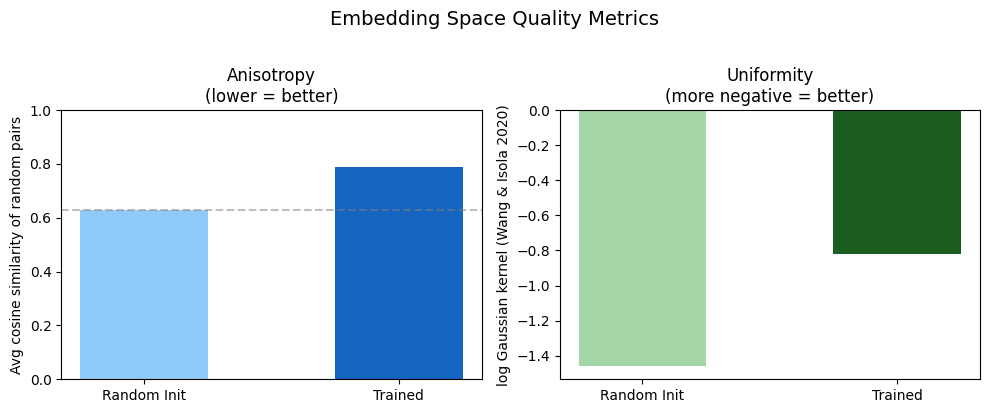

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/metrics_bar.png


In [4]:
## Step 4: Anisotropy and Uniformity Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Anisotropy — lower is better
axes[0].bar(["Random Init", "Trained"],
            [metrics["random_anisotropy"], metrics["trained_anisotropy"]],
            color=["#90CAF9", "#1565C0"], width=0.5)
axes[0].set_title("Anisotropy\n(lower = better)", fontsize=12)
axes[0].set_ylabel("Avg cosine similarity of random pairs")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=metrics["random_anisotropy"], color="gray",
                linestyle="--", alpha=0.5)

# Uniformity — more negative is better
axes[1].bar(["Random Init", "Trained"],
            [metrics["random_uniformity"], metrics["trained_uniformity"]],
            color=["#A5D6A7", "#1B5E20"], width=0.5)
axes[1].set_title("Uniformity\n(more negative = better)", fontsize=12)
axes[1].set_ylabel("log Gaussian kernel (Wang & Isola 2020)")

plt.suptitle("Embedding Space Quality Metrics", fontsize=14, y=1.02)
plt.tight_layout()
save_path = "outputs/metrics_bar.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

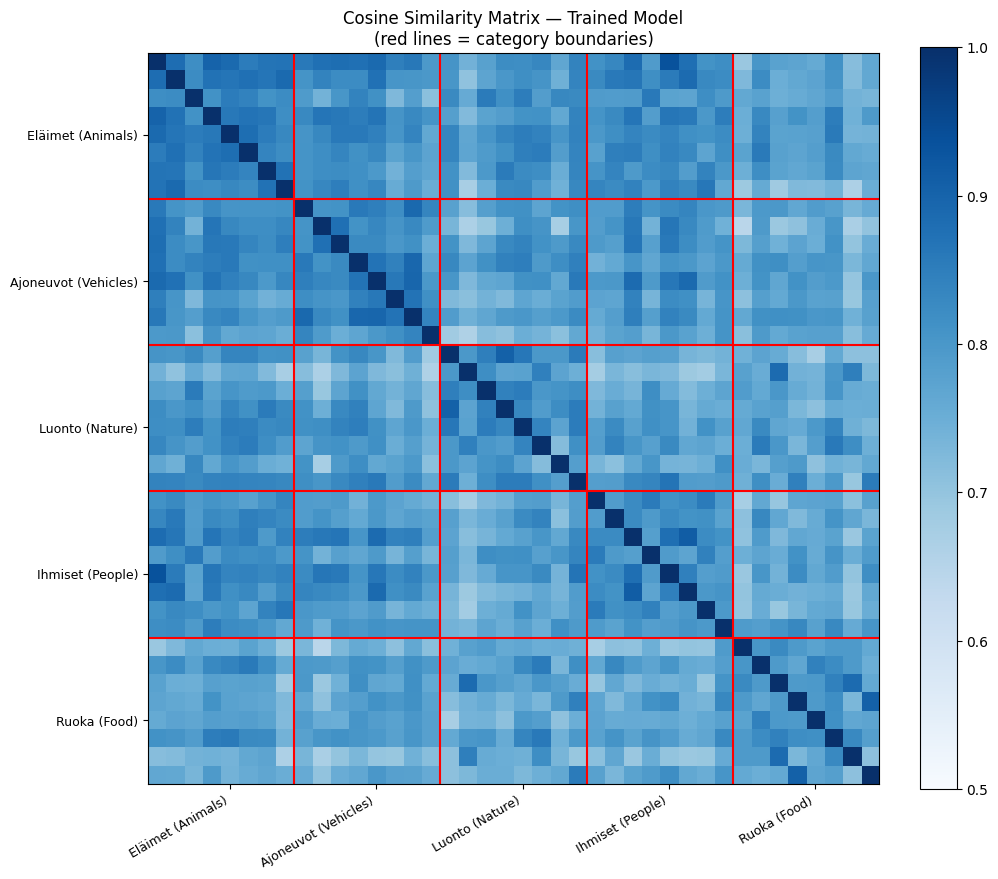

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/similarity_heatmap.png


In [5]:
## Step 5: Cosine Similarity Heatmap (Trained Model)

# Full 40×40 cosine similarity matrix
# L2-normalised embeddings → dot product == cosine similarity
sim_matrix = torch.mm(trained_embs, trained_embs.T).numpy()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, fraction=0.046)

# Draw red lines at category boundaries
category_sizes = [len(s) for s in categories.values()]
boundaries = [0]
for s in category_sizes:
    boundaries.append(boundaries[-1] + s)

for b in boundaries[1:-1]:
    ax.axhline(y=b - 0.5, color="red", linewidth=1.5)
    ax.axvline(x=b - 0.5, color="red", linewidth=1.5)

# Category centre tick positions
category_centers = [(boundaries[i] + boundaries[i + 1]) / 2
                    for i in range(len(boundaries) - 1)]
cat_labels = list(categories.keys())
ax.set_xticks(category_centers)
ax.set_xticklabels(cat_labels, rotation=30, ha="right", fontsize=9)
ax.set_yticks(category_centers)
ax.set_yticklabels(cat_labels, fontsize=9)

ax.set_title("Cosine Similarity Matrix \u2014 Trained Model\n"
             "(red lines = category boundaries)", fontsize=12)
plt.tight_layout()
save_path = "outputs/similarity_heatmap.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

/Users/tyerdogan/PycharmProjects/finnish-embeddings/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


t-SNE finished for Trained Model
t-SNE finished for Random Init


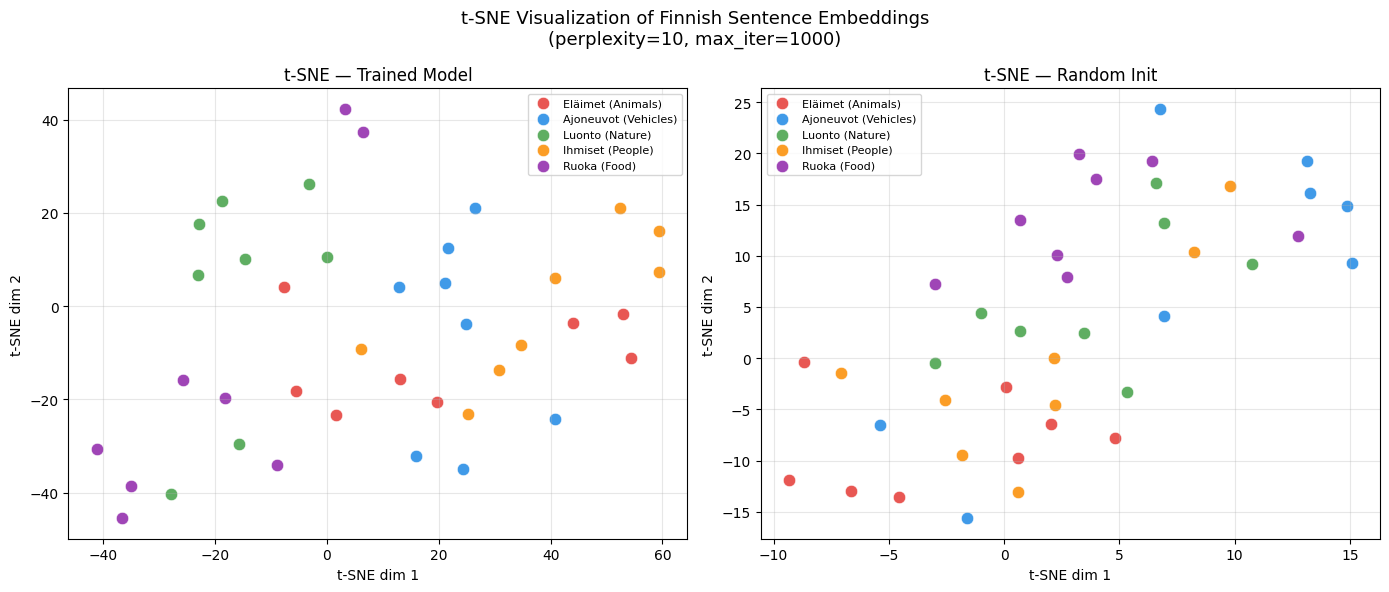

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/tsne.png


In [6]:
## Step 6: t-SNE Visualisation
# perplexity=10: appropriate for N=40 (van der Maaten 2008 recommends perplexity << N)
# PERPLEXITY is set low because we only have 40 sentences.
PERPLEXITY = 10
N_ITER     = 1000

# One integer label per sentence indicating its category index
COLORS    = ["#E53935", "#1E88E5", "#43A047", "#FB8C00", "#8E24AA"]
cat_names = list(categories.keys())
labels    = []
for cat_name, sents in categories.items():
    labels.extend([cat_names.index(cat_name)] * len(sents))
labels    = np.array(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (embs, title) in zip(axes, [
    (trained_embs.numpy(), "Trained Model"),
    (random_embs.numpy(),  "Random Init"),
]):
    tsne = TSNE(n_components=2, perplexity=PERPLEXITY,
                random_state=42, max_iter=N_ITER, verbose=0)
    embs_2d = tsne.fit_transform(embs)
    print(f"t-SNE finished for {title}")

    for i, cat_name in enumerate(cat_names):
        mask = labels == i
        ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
                   c=COLORS[i], label=cat_name,
                   s=80, alpha=0.85, edgecolors="white", linewidth=0.5)

    ax.set_title(f"t-SNE \u2014 {title}", fontsize=12)
    ax.legend(fontsize=8, loc="best")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE Visualization of Finnish Sentence Embeddings\n"
             f"(perplexity={PERPLEXITY}, max_iter={N_ITER})", fontsize=13)
plt.tight_layout()
save_path = "outputs/tsne.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

In [7]:
## Step 7: Nearest-Neighbour Search (Trained Model)
# One query per category — first sentence of each.
category_names_list = list(categories.keys())
query_sentences     = [sents[0] for sents in categories.values()]
query_indices       = [sentences.index(s) for s in query_sentences]
query_embs          = trained_embs[query_indices]   # (5, 256)

# top_k=4 so self-match (rank 1) can be skipped, leaving 3 true neighbours
nn_results = ev.nearest_neighbor_search(
    query_embs, trained_embs, sentences, top_k=4
)

print("Nearest Neighbour Search \u2014 Trained Model")
print("=" * 70)
for cat_name, query_sent, hits in zip(
    category_names_list, query_sentences, nn_results
):
    print(f"\nCategory : {cat_name}")
    print(f"  Query  : {query_sent}")
    rank = 0
    for sent, score in hits:
        if sent == query_sent:
            continue  # skip self-match
        rank += 1
        print(f"  {rank}. [{score:.4f}]  {sent}")

Nearest Neighbour Search — Trained Model

Category : Eläimet (Animals)
  Query  : Koira juoksi puistossa.
  1. [0.9342]  Lapset juoksivat puistossa.
  2. [0.9023]  Hevonen juoksi pellolla.
  3. [0.8882]  Kala ui järvessä.

Category : Ajoneuvot (Vehicles)
  Query  : Auto ajoi nopeasti tiellä.
  1. [0.8900]  Moottoripyörä ajoi ohi.
  2. [0.8585]  Lentokone lensi pilvien yli.
  3. [0.8580]  Koira juoksi puistossa.

Category : Luonto (Nature)
  Query  : Aurinko paistoi kirkkaasti.
  1. [0.9048]  Tuuli puhalsi voimakkaasti.
  2. [0.8630]  Sade kaatoi läpi yön.
  3. [0.8548]  Pilvet liikkuivat hitaasti.

Category : Ihmiset (People)
  Query  : Hän luki kirjaa hiljaa.
  1. [0.8542]  Nainen lauloi kauniisti.
  2. [0.8538]  Tyttö piirsi kuvaa.
  3. [0.8352]  Kissa katsoi ikkunasta.

Category : Ruoka (Food)
  Query  : Leipä oli tuoretta ja pehmeää.
  1. [0.8269]  Keitto oli lämmin ja maukas.
  2. [0.8024]  Kahvi maistui hyvältä aamulla.
  3. [0.7946]  Kala oli paistettu hyvin.


Avg intra-category similarity : 0.8221
Avg inter-category similarity : 0.7837
Ratio (intra / inter)         : 1.049

Interpretation:
  Ratio > 1.0 → model distinguishes categories
  Higher ratio → better semantic clustering


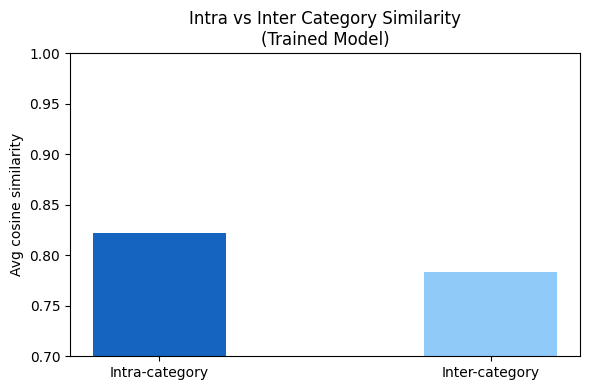

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/intra_inter.png


In [8]:
## Step 8: Intra- vs Inter-Category Similarity
# cat_names and labels are defined in Step 6 (t-SNE).
# If Step 6 was not run, this cell would raise NameError.
# Redefine defensively as a safety fallback.
if "cat_names" not in globals():
    cat_names = list(categories.keys())
    labels = []
    for cat_name, sents in categories.items():
        labels.extend([cat_names.index(cat_name)] * len(sents))
    labels = np.array(labels)

# Measures whether the model clusters same-category sentences closer together.
n_cats = len(cat_names)
sim_np = torch.mm(trained_embs, trained_embs.T).numpy()

intra = []
inter = []

for i in range(n_cats):
    for j in range(n_cats):
        mask_i = labels == i
        mask_j = labels == j
        block  = sim_np[np.ix_(mask_i, mask_j)]
        if i == j:
            # Upper triangle only — excludes self-similarity (diagonal = 1.0)
            n    = block.shape[0]
            vals = [block[r, c] for r in range(n) for c in range(r + 1, n)]
            if vals:
                intra.append(np.mean(vals))
        else:
            inter.append(block.mean())

print(f"Avg intra-category similarity : {np.mean(intra):.4f}")
print(f"Avg inter-category similarity : {np.mean(inter):.4f}")
print(f"Ratio (intra / inter)         : {np.mean(intra) / np.mean(inter):.3f}")
print()
print("Interpretation:")
print("  Ratio > 1.0 \u2192 model distinguishes categories")
print("  Higher ratio \u2192 better semantic clustering")

fig, ax = plt.subplots(figsize=(6, 4))
## Step 8a: Bar chart
ax.bar(["Intra-category", "Inter-category"],
       [np.mean(intra), np.mean(inter)],
       color=["#1565C0", "#90CAF9"], width=0.4)
ax.set_ylabel("Avg cosine similarity")
ax.set_title("Intra vs Inter Category Similarity\n(Trained Model)")
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
save_path = "outputs/intra_inter.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

## Evaluation Summary

| Metric | Random Init | Trained | Direction |
|--------|------------|---------|----------|
| Anisotropy | 0.6308 | 0.7897 | ↑ worse |
| Uniformity | -1.4611 | -0.8196 | ↑ worse |
| Intra/Inter ratio | — | 1.049 | slightly higher than 1 |

### Observations

- The trained model produces some meaningful nearest-neighbour results, especially for nature, food, and partially vehicles.
- However, the nearest-neighbour search is not fully category-consistent. Some retrieved sentences come from different semantic categories, suggesting that the model may rely partly on surface-level patterns such as shared verbs, locations, or sentence structure.
- MLM pre-training increased anisotropy: trained embeddings became more concentrated in the vector space compared with the random baseline.
- Uniformity also became worse after training, meaning that the embeddings are less evenly distributed on the hypersphere.
- The intra/inter-category ratio is above 1.0, but only slightly. This suggests weak but observable category-level structure rather than strong semantic clustering.
- Overall, the model learned useful Finnish contextual representations, but it should not yet be treated as a strong sentence embedding model. Contrastive fine-tuning such as SimCSE would likely be needed to improve semantic separation and reduce anisotropy.